# Pair Plots: Visualizing Relationships Between Multiple Variables

Now that we've gone through scatterplots, histograms, and continuous KDE plots, you have everything you need to understand a quite useful plot. **Pair plots** are convenient ways to visualize relationships between **multiple continuous variables**
in a single figure.

Pair plots are useful because they automatically display:
- **scatterplots** for each pair of continuous variables
- **marginal distributions** on the diagonal

This gives you a quick overview of pairwise relationships among all continuous variables in a DataFrame. You might be able to quickly identify any patterns that look linear, non-linear, or appear to be clustering. From there, you can create scatterplots between specific pairs of variables of interest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Penguins Dataset

We’ll use Seaborn’s built-in `penguins` dataset to illustrate pair plots.

In [2]:
penguins = sns.load_dataset("penguins")
penguins.info()
penguins.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Basic Pair Plot

A basic pair plot shows:
- scatterplots for each pair of numeric variables
- marginal (single-variable) distributions on the diagonal

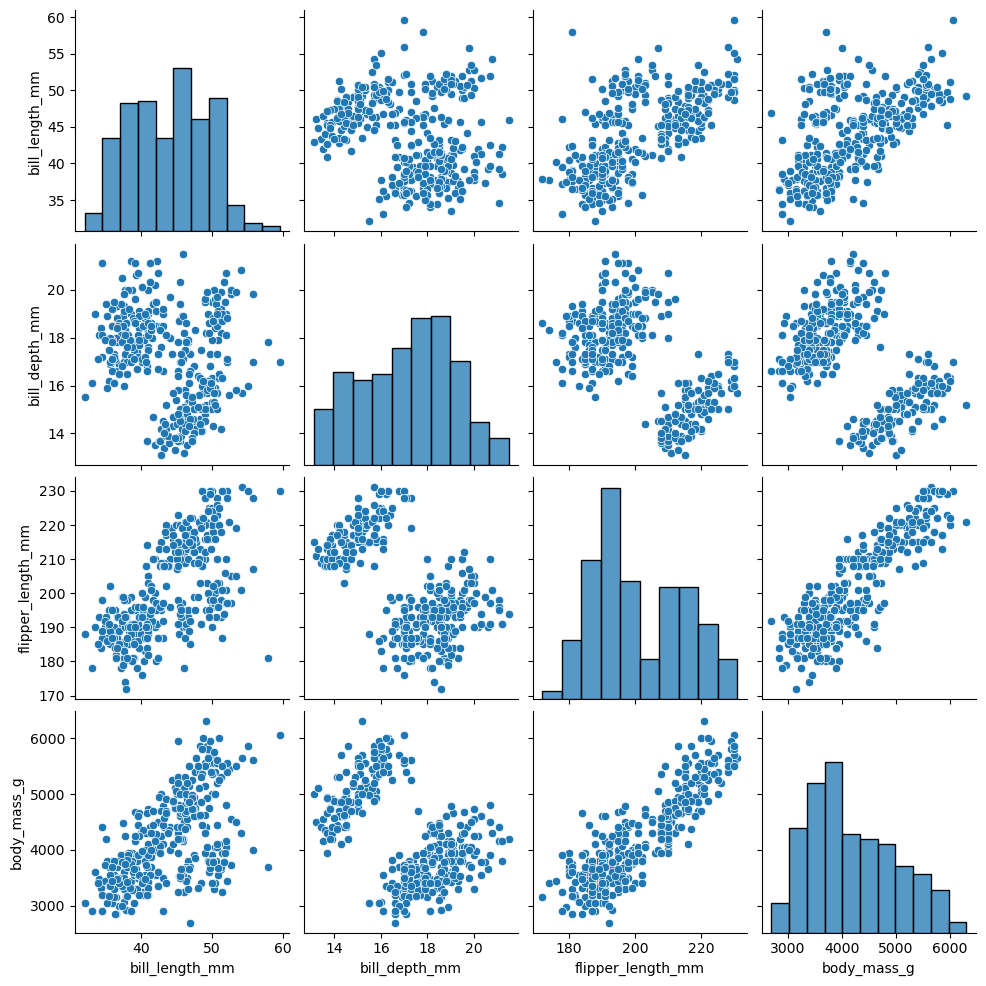

In [3]:
sns.pairplot(data=penguins)
plt.show()

That was easy! This illustrates how pair plots can be used to quickly view scatterplots between all continuous variables and histograms for marginal distributions of continuous variables.

## Conditioning on a Categorical Variable with `hue`

We can group the data by a categorical variable and use **color** to distinguish the groups.

Here, we color the points by `species`. Note that `pairplot` now gives conditional KDE plots on the diagonal.

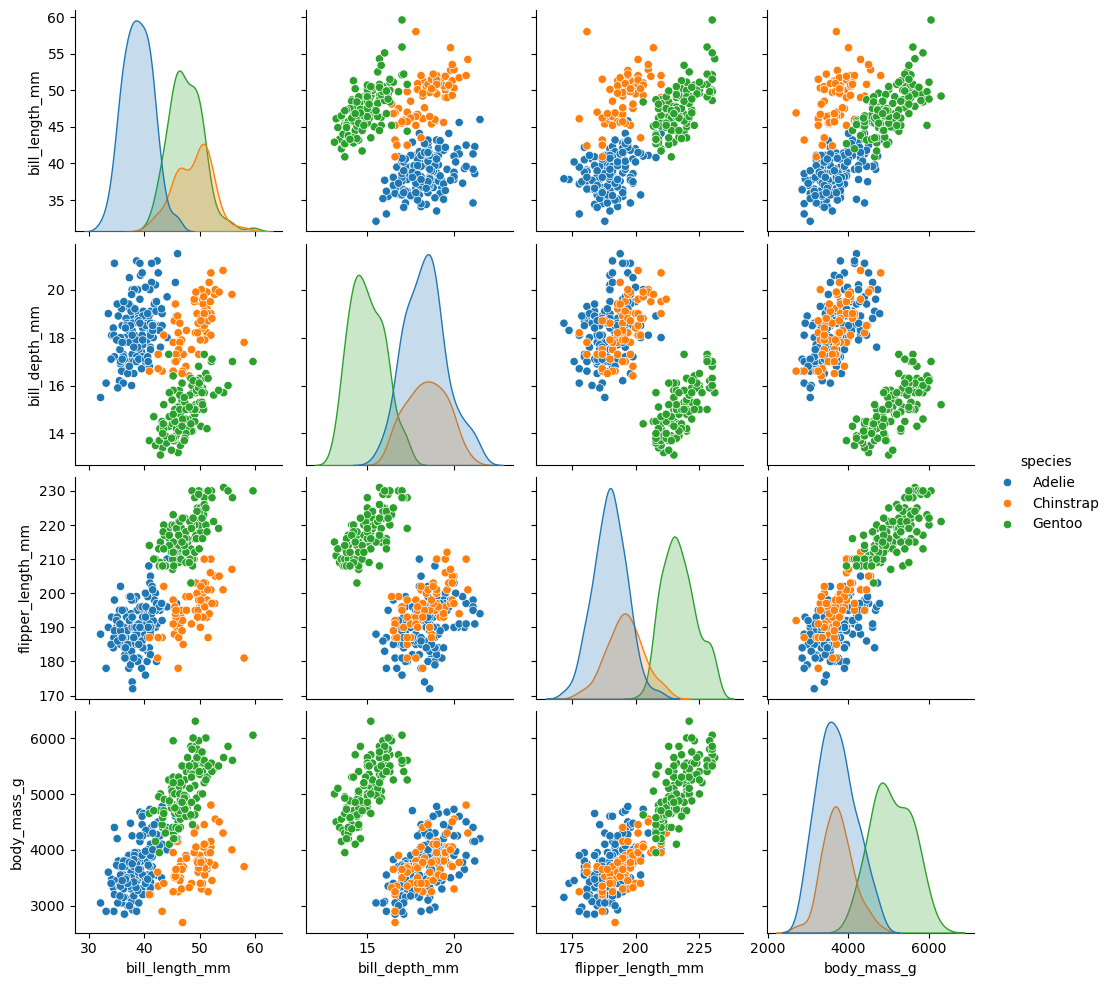

In [4]:
sns.pairplot(data=penguins, hue="species")
plt.show()

## Removing the Sample Size Effect on Diagonal KDE Plots

When you pass a categorical variable to `hue`, Seaborn keeps the effect of sample size when drawing KDE curves on the diagonal. That means categories with fewer data points overall may appear to have
smaller densities.

If your goal is to compare the **shape** of the distributions within each category
rather than compare group sizes, use:

```python
diag_kws={"common_norm": False}
```

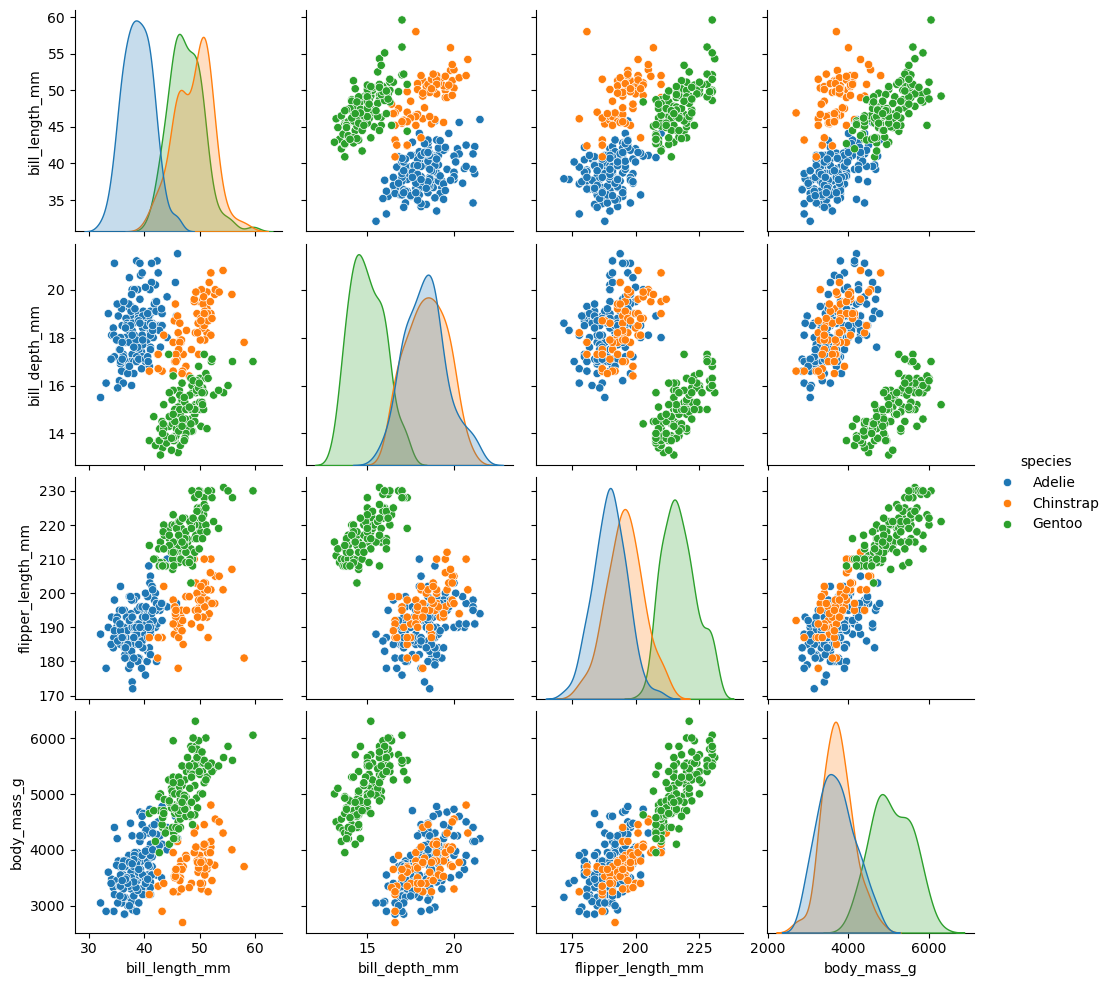

In [5]:
sns.pairplot(data=penguins, hue="species", diag_kws={"common_norm": False})
plt.show()

By default, Seaborn accounts for sample size when scaling the diagonal KDE plots.

With `common_norm=False`:
- each group’s diagonal distribution is normalized separately
- smaller groups do not automatically get smaller-looking density curves
- it becomes easier to compare the **distribution shape** across groups

## Important Note: Don’t Use Too Many Variables

An important limitation of pair plots is that they become very crowded if you include too many variables.

A practical guideline:
- Use pair plots when you have a **small to moderate number of numeric variables**
- Around **20 variables at most**, but usually much fewer is better

For most exploratory analysis, pair plots work best with about **3 to 6 variables**.

You can specify variables of interest with the `vars` argument of `pairplot`:

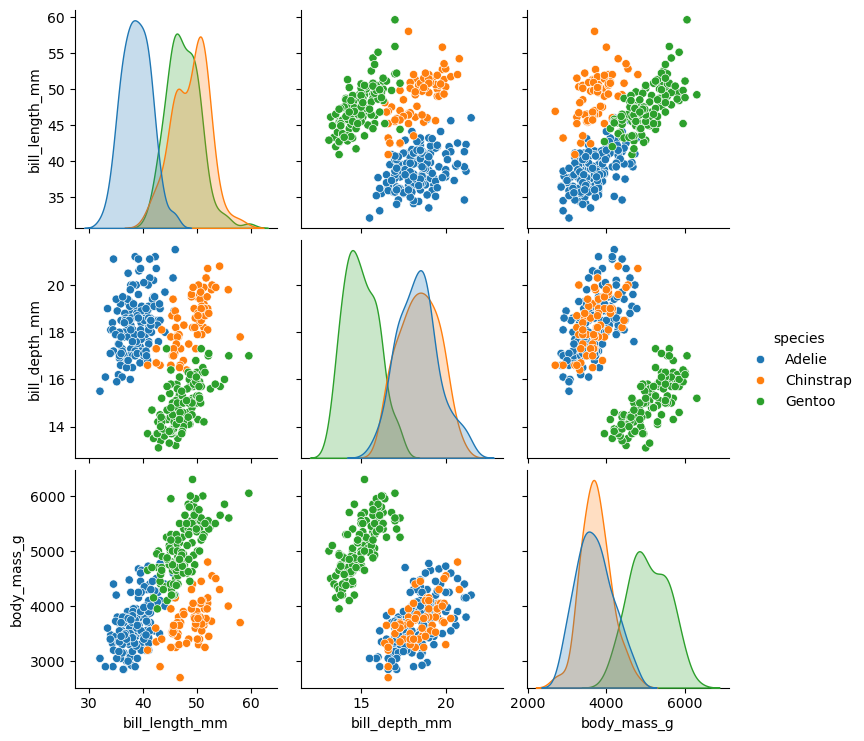

In [6]:
sns.pairplot(data=penguins, vars=["bill_length_mm", "bill_depth_mm", "body_mass_g"],
             hue="species", diag_kws={"common_norm": False})
plt.show()

## Summary

- `sns.pairplot()` is a fast way to visualize relationships between multiple continuous variables.
- Off-diagonal plots show pairwise scatterplots.
- Diagonal plots show marginal distributions.
- Use `hue=` to condition on a categorical variable.
- Use `diag_kws={"common_norm": False}` when you want to compare the **shape** of group distributions without sample size affecting the diagonal KDE heights.
- Pair plots are most useful when the number of variables is not too large.

## Practice Exercises

2. Create a pair plot of the Palmer Penguins dataset grouped/colored by a variable other than `species`.
3. In 1–2 sentences, describe one relationship you observe from the pair plot.